In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


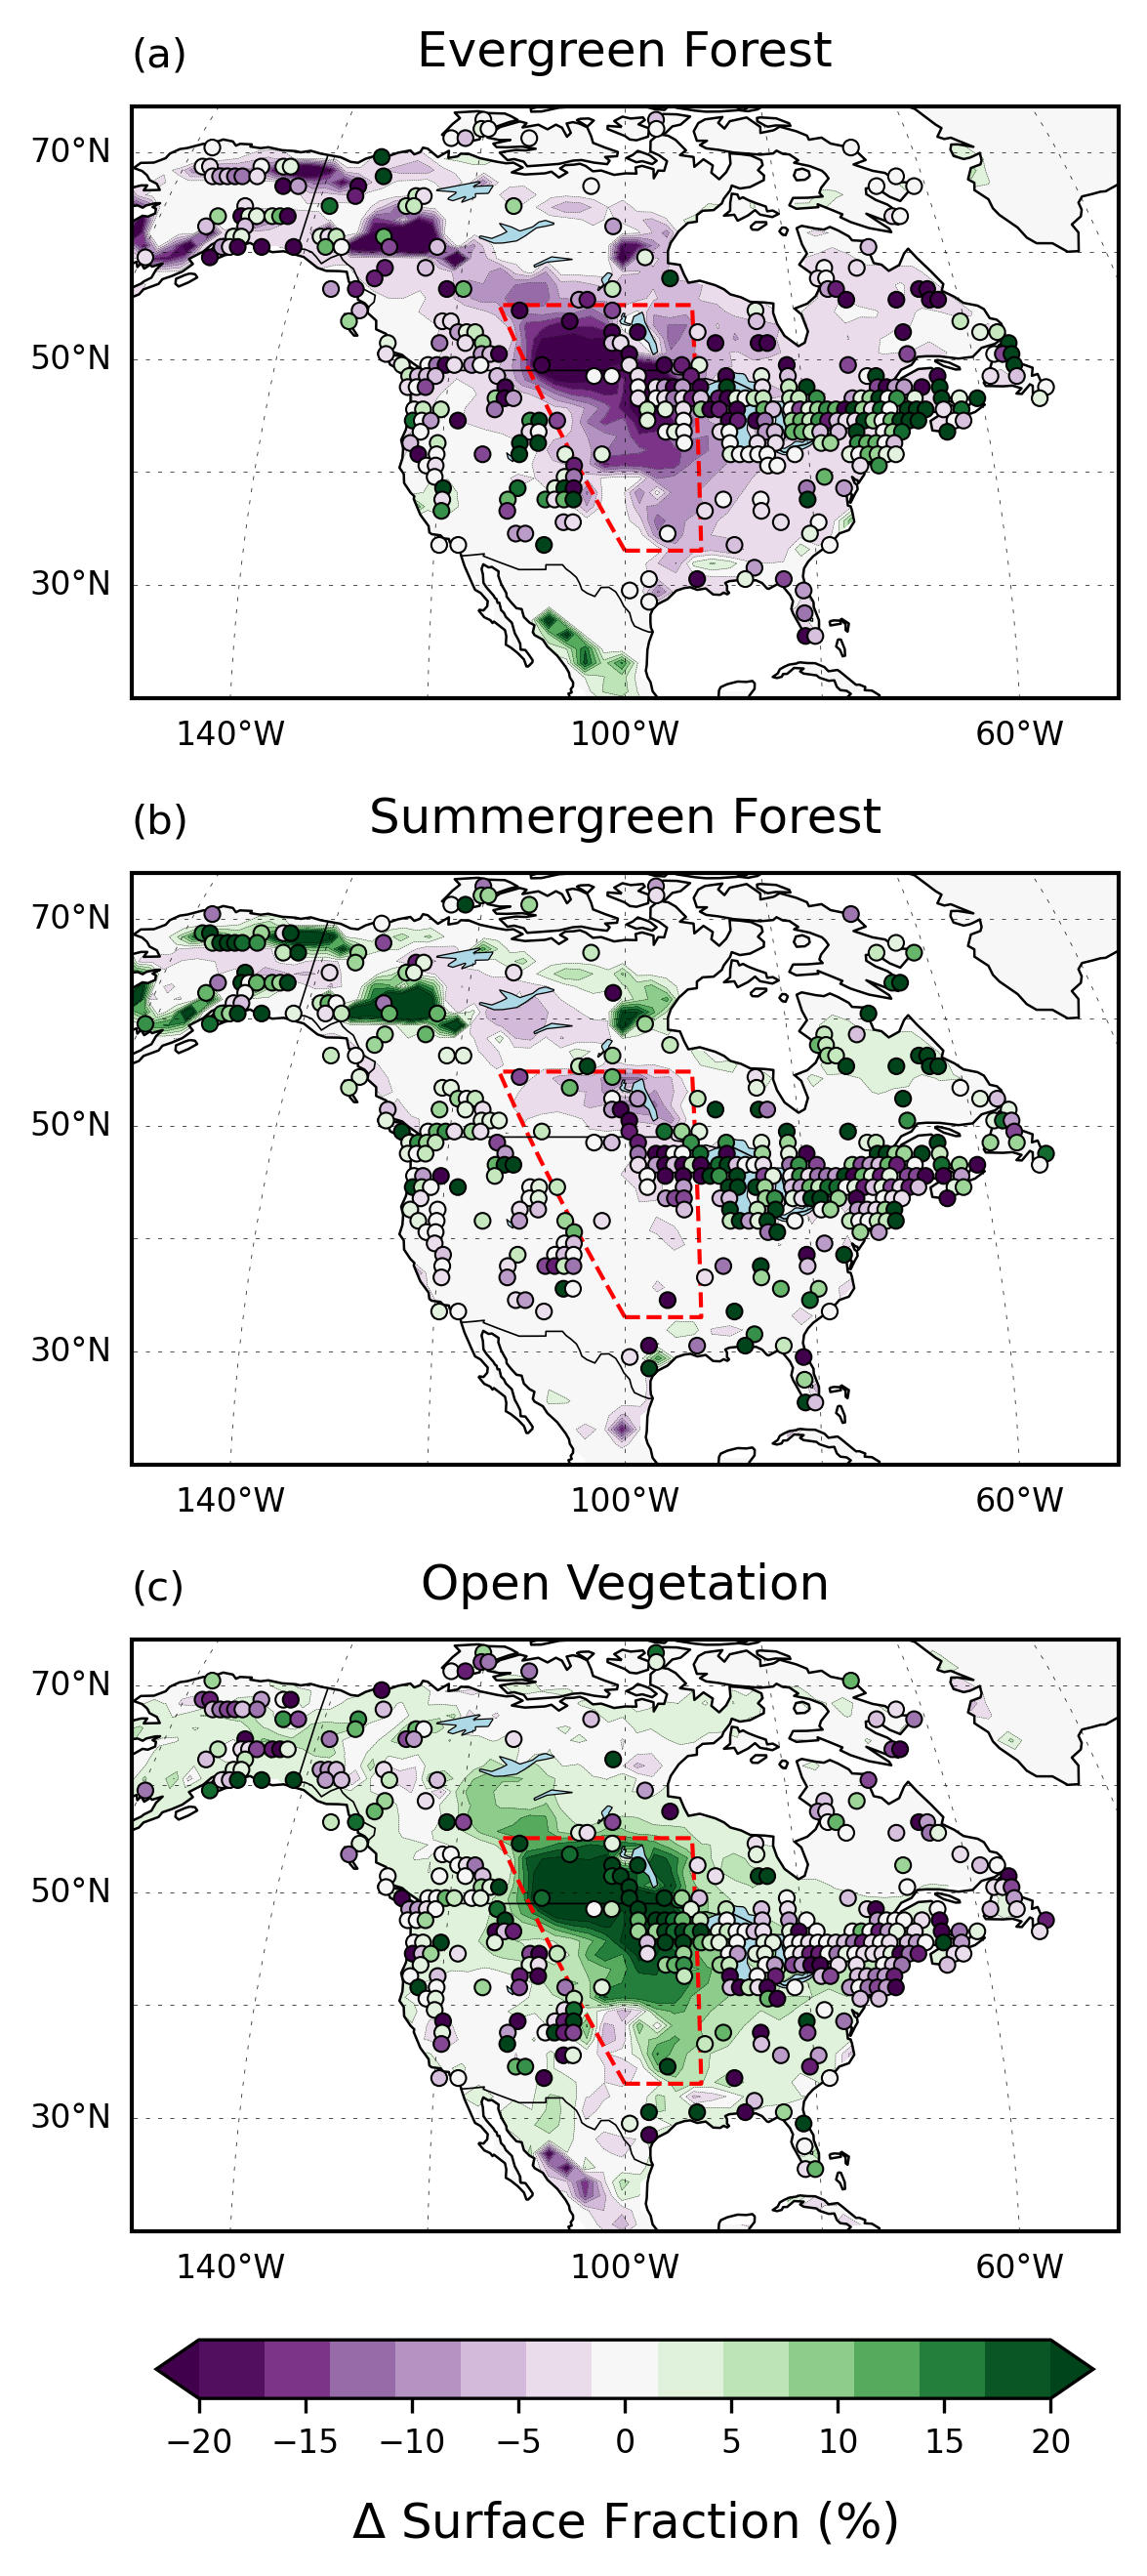

In [ ]:
#------------------------------------------------------------
# Import Surface Fractions and convert to % coverage
#------------------------------------------------------------

mh_sfrac = um.importUMData(f"../Data/Monthly_Means/MH_monthly_means_197001-204912.nc")["surfacefrac"] * 100
pi_sfrac = um.importUMData(f"../Data/Monthly_Means/PI_monthly_means_187001-194912.nc")["surfacefrac"] * 100
LON, LAT = np.meshgrid(mh_sfrac.longitude, mh_sfrac.latitude)

#------------------------------------------------------------
# Import Dawson vegetation reconstructions for PI (200) and 
# MH (6000) timeslices
#------------------------------------------------------------

dawson_vars = ["ET", "ST", "OL"]
df200, df6k = um.importRevealsYrs(f"../Data/REVEALS_LCT_gridded.csv", [200, 6000])
dawson_lon, dawson_lat = df200["x"], df200["y"]
for var in dawson_vars:
    df200[var] = df200[var] * 100
    df6k[var] = df6k[var] * 100

#------------------------------------------------------------
# Plot Properties
#------------------------------------------------------------

lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)
PFTS = {"Evergreen Forest": [1, 2, 4, 12], "Summergreen Forest": [0, 3, 11], "Open Vegetation": [5, 6, 7, 8, 9, 10]}
labels = ['a', 'b', 'c']
cmap = cm.PRGn; v = 20; levs = np.linspace(-v, v, 14); cbar_lab = r"$\Delta$ Surface Fraction (%)"
norm = BoundaryNorm(levs, cmap.N, extend="both")

GP_region = umplt.umRegion("GP")

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

fig = plt.figure(figsize=(4, 8), dpi=300)
gs = gridspec.GridSpec(3, 1)

for i, pft in enumerate(PFTS.keys()):
    ax = plt.subplot(gs[i], projection=proj)
    umplt.plotBaseMap(ax, lims, coastlw=0.6, ocean=True, oceancol="white", bordercol="black", borderlw=0.4)
    ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue", linewidth=0.3, zorder=1)

    umplt.plotGrid(ax, xlabeledlines=[-60,-100,-140], ylabeledlines=[30,50,70],
                   xlines=[-40,-80,-120,-160], ylines=[40,60], labelsize=8, lw=0.2)
    
    del_sfrac = mh_sfrac[:, PFTS[pft]].sum(dim="surface_tiles", min_count=1).squeeze().mean(dim="time") - pi_sfrac[:, PFTS[pft]].sum(dim="surface_tiles", min_count=1).squeeze().mean(dim="time")

    cf1 = ax.contourf(LON, LAT, del_sfrac, extend="both", cmap=cmap, levels=levs, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    contour = ax.contour(LON, LAT, del_sfrac, extend="both", colors="black", levels=levs, linestyles="dashed", linewidths=0.1, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

    line_kws = {"color": "red", "linestyle": "dashed", "linewidth": 1, "zorder": 0}
    GP_region.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

    ax.set_title(f"({labels[i]})", loc="left", fontsize=10, pad=10)
    ax.set_title(pft, fontsize=12, pad=10)

    DAWSON = df6k[dawson_vars[i]].values - df200[dawson_vars[i]].values

    p1 = ax.scatter(dawson_lon, dawson_lat, c=DAWSON, s=15, marker="o", cmap=cmap, norm=norm, edgecolors="black", linewidths=0.5, transform=ccrs.PlateCarree(), zorder=2)
    
cbaxes = fig.add_axes((0.1385, -0.03, 0.8, 0.025))
cbar = plt.colorbar(cf1, extend='both', orientation='horizontal', ticks=np.linspace(-v, v, 9), cax=cbaxes)
cbar.ax.tick_params(labelsize=8) 
cbar.set_label(label=cbar_lab, size=12, labelpad=10)

plt.tight_layout()
plt.show()